In [1]:
import keras
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = "mu3e_trigger_data"
SIGNAL_DATA_FILE = f"{DATA_DIR}/run42_sig_positions.npy"
BACKGROUND_DATA_FILE = f"{DATA_DIR}/run42_bg_positions.npy"

max_barrel_radius = 86.3
max_endcap_distance = 372.6

In [3]:
signal_data = np.load(SIGNAL_DATA_FILE)
background_data = np.load(BACKGROUND_DATA_FILE)

background_data[background_data[:, :, 0] != -1, 0] = (
    background_data[background_data[:, :, 0] != -1, 0]
) / max_barrel_radius
background_data[background_data[:, :, 0] != -1, 1] = (
    background_data[background_data[:, :, 0] != -1, 1]
) / max_barrel_radius
background_data[background_data[:, :, 0] != -1, 2] = (
    background_data[background_data[:, :, 0] != -1, 2] 
) / max_endcap_distance

signal_data[signal_data[:, :, 0] != -1, 0] = (
    signal_data[signal_data[:, :, 0] != -1, 0]
) / max_barrel_radius
signal_data[signal_data[:, :, 0] != -1, 1] = (
    signal_data[signal_data[:, :, 0] != -1, 1]
) / max_barrel_radius
signal_data[signal_data[:, :, 0] != -1, 2] = (
    signal_data[signal_data[:, :, 0] != -1, 2] 
) / max_endcap_distance

In [4]:
# Transfrom data to cyclic coordinates
r_bg = np.sqrt(background_data[:, :, 0] ** 2 + background_data[:, :, 1] ** 2)
phi_bg = np.arctan2(background_data[:, :, 1], background_data[:, :, 0])
z_bg = background_data[:, :, 2]
background_data_cyclindric = np.stack([r_bg, phi_bg, z_bg], axis=-1)
background_data_cyclindric[background_data[:, :, 0] == -1, :] = -1

In [5]:
class MMDLoss(keras.losses.Loss):
    def __init__(self, latent_dim, kernel="rbf", sigma=1.0, weight=1.0, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim
        self.kernel = kernel
        self.sigma = sigma
        self.weight = weight

    def call(self, y_true, y_pred):
        z = y_pred  # shape: (batch_size, latent_dim)
        batch_size = tf.shape(z)[0]
        prior = tf.random.normal(
            shape=(batch_size, self.latent_dim)
        )  # standard Gaussian

        return self.weight * self._mmd(z, prior)

    def _mmd(self, x, y):
        xx = self._compute_kernel(x, x)
        yy = self._compute_kernel(y, y)
        xy = self._compute_kernel(x, y)
        return tf.reduce_mean(xx + yy - 2 * xy)

    def _compute_kernel(self, x, y):
        x = tf.expand_dims(x, 1)  # shape: (batch, 1, dim)
        y = tf.expand_dims(y, 0)  # shape: (1, batch, dim)
        dist = tf.reduce_sum((x - y) ** 2, axis=2)
        return tf.exp(-dist / (2 * self.sigma**2))


class SlicedWassersteinLoss(keras.losses.Loss):
    def __init__(self, latent_dim, num_projections=100, weight=1.0, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim
        self.num_projections = num_projections
        self.weight = weight

    def call(self, y_true, y_pred):
        z = y_pred  # shape: (batch_size, latent_dim)
        batch_size = tf.shape(z)[0]

        proj_vectors = tf.random.normal((self.num_projections, self.latent_dim))
        proj_vectors = tf.math.l2_normalize(
            proj_vectors, axis=1
        )  # shape: (num_proj, latent_dim)

        z_proj = tf.matmul(
            z, proj_vectors, transpose_b=True
        )  # shape: (batch, num_proj)
        prior = tf.random.normal((batch_size, self.latent_dim))
        prior_proj = tf.matmul(prior, proj_vectors, transpose_b=True)

        z_sorted = tf.sort(z_proj, axis=0)
        prior_sorted = tf.sort(prior_proj, axis=0)

        return self.weight * tf.reduce_mean(tf.square(z_sorted - prior_sorted))


class UnitHyperSphereCoverLoss(keras.losses.Loss):
    def __init__(self, latent_dim, temperature, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim
        self.temperature = temperature

    def call(self, y_true, y_pred):
        z = y_pred  # shape: (batch_size, latent_dim)
        batch_size = tf.shape(z)[0]
        z = tf.math.l2_normalize(z, axis=1)

        # Compute pairwise squared distances
        # Using ||x - y||^2 = ||x||^2 + ||y||^2 - 2 * x^T y
        similarity_matrix = tf.matmul(z, z, transpose_b=True)
        sq_dists = 2.0 - 2.0 * similarity_matrix  # since ||z|| = 1

        # Remove diagonal (self-pairs)
        mask = tf.ones_like(sq_dists) - tf.eye(batch_size)
        sq_dists_no_diag = (
            sq_dists * mask
        )  # Compute the loss as the mean of the distances
        exp_dists = tf.exp(-self.temperature * sq_dists_no_diag)
        mean_exp = tf.reduce_sum(exp_dists) / tf.cast(
            batch_size * (batch_size - 1), tf.float32
        )
        return tf.math.log(mean_exp + 1e-6) / self.temperature


class CovarianceLoss(keras.losses.Loss):
    def __init__(self, latent_dim, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim

    def call(self, y_true, y_pred):
        z = y_pred  # shape: (batch_size, latent_dim)
        batch_size = tf.cast(tf.shape(z)[0], tf.float32)
        z_size = tf.cast(tf.shape(z)[1], tf.float32)

        # Compute covariance matrix
        z_centered = z - tf.reduce_mean(z, axis=0)
        cov_matrix = tf.matmul(z_centered, z_centered, transpose_a=True) / (
            batch_size - 1.0
        )

        off_diag_mask = 1.0 - tf.eye(z_size)
        loss = tf.reduce_sum(tf.square(cov_matrix * off_diag_mask)) / z_size
        return loss

In [6]:
class EncodingLoss(keras.losses.Loss):
    def __init__(self, latent_dim, diversity_encouragement=1, name=None):
        super().__init__(name)
        self.diversity_encouragement = diversity_encouragement
        self.covariance_loss = CovarianceLoss(latent_dim=latent_dim)
        self.dist_loss = UnitHyperSphereCoverLoss(latent_dim=latent_dim, temperature=1)

    def call(self, y_true, y_pred):
        latent_dim = y_pred.shape[-1] // 2
        z, ae_output = tf.split(y_pred, [latent_dim, latent_dim], axis=-1)
        ae_loss = tf.reduce_mean(tf.square(z - ae_output))

        # include a regularization term to encourage diversity in the latent space to encourage the model to learn a variance of 1
        if self.diversity_encouragement > 0:
            diversity_loss = tf.reduce_mean(
                tf.maximum(
                    0.0,
                    1
                    - tf.sqrt(
                        tf.math.reduce_variance(z, axis=0)
                        + 1e-5
                    ),
                )
            )
        else:
            diversity_loss = 0.0


        if self.diversity_encouragement > 0:
            per_event_diversity_loss = tf.reduce_mean(
                tf.maximum(
                    0.0,
                    1
                    - tf.sqrt(
                        tf.math.reduce_variance(z, axis=1)
                        + 1e-5
                    ),
                )
            )
        else:
            per_event_diversity_loss = 0.0


        return (
            ae_loss
            + (self.diversity_encouragement + self.covariance_loss(z, z) + self.dist_loss(z,z) + per_event_diversity_loss) * diversity_loss
        )


class AutoEncodingLoss(keras.losses.Loss):
    def __init__(self, name=None):
        super().__init__(name)

    def call(self, y_true, y_pred):
        latent_dim = y_pred.shape[-1] // 2
        z, ae_output = tf.split(y_pred, [latent_dim, latent_dim], axis=-1)
        ae_loss = tf.reduce_mean(tf.square(z - ae_output))

        return ae_loss


class ReconstructionQuality(keras.metrics.Metric):
    def __init__(self, name="reconstruction_quality", **kwargs):
        super().__init__(name=name, **kwargs)
        self.total_loss = self.add_weight(name="total_loss", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        latent_dim = y_pred.shape[-1] // 2
        z, ae_output = tf.split(y_pred, [latent_dim, latent_dim], axis=-1)
        loss = tf.reduce_mean(tf.square(z - ae_output))
        self.total_loss.assign_add(loss)
        self.count.assign_add(1)

    def result(self):
        return self.total_loss / self.count


class FeatureVariance(keras.metrics.Metric):
    def __init__(self, name="feature_variance", **kwargs):
        super().__init__(name=name, **kwargs)
        self.variance = self.add_weight(name="variance", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        latent_dim = y_pred.shape[-1] // 2
        z, ae_output = tf.split(y_pred, [latent_dim, latent_dim], axis=-1)
        variance = tf.math.reduce_variance(z, axis=0)
        self.variance.assign_add(tf.reduce_mean(variance))
        self.count.assign_add(1)

    def result(self):
        return self.variance / self.count

In [7]:
sequence_length = 256
feature_dim = 3
hidden_dim = 8
latent_dim = 32

In [8]:
from src.model.components import (
    SelfAttentionStack,
    MLP,
    PoolingAttentionBlock,
    PointTransformerFromCoords,
    DecoderQueries,
    MultiHeadAttentionBlock,
)
from src.model.components import (
    GenerateDecoderMask,
    GenerateMask,
    MaskOutput,
    GetSequenceLength,
)

# Fixed size encoding models
input = keras.Input(shape=(sequence_length, feature_dim), name="input")
mask = GenerateMask(name="generate_mask")(input)
sequence_length_layer = GetSequenceLength(name="get_sequence_length")(mask)

if False:
    input_embedding = PointTransformerFromCoords(
        name="point_transformer_from_coords",
        feature_dim=hidden_dim,
        pos_mlp_hidden_dim=hidden_dim,
        attn_mlp_hidden_dim=hidden_dim,
    )(input, mask)
else:
    input_embedding = MLP(
        name="input_embedding",
        output_dim=hidden_dim,
        num_layers=3,
        activation="relu",)(input)


lstm_1 = keras.layers.Bidirectional(keras.layers.LSTM(
    units=hidden_dim,
    return_sequences=True,
    return_state=False,
    name="lstm",
))(input_embedding, mask = mask)

lstm_2 = keras.layers.Bidirectional(keras.layers.LSTM(
    units=hidden_dim,
    return_sequences=False,
    return_state=False,
    name="lstm_2",
))(lstm_1, mask = mask)



fixed_size_encoding = MLP(name="fixed_size_encoding", output_dim=latent_dim, num_layers=3)(
    lstm_2
)
fixed_size_encoding = keras.layers.Flatten(name="flatten")(fixed_size_encoding)

# fixed_size_encoding = MLP(name="mlp", output_dim=1)(fixed_size_encoding)

# Autoencoder model
encoder = MLP(name="encoder", output_dim=int(latent_dim / 2), num_layers=4)
decoder = MLP(name="decoder", output_dim=latent_dim, num_layers=4)

output = keras.layers.Concatenate(name="concatenate")(
    [fixed_size_encoding, decoder(encoder(fixed_size_encoding))]
)

# Define model
autoencoder_layers = [encoder, decoder]
# A: Embedding Model (input to fixed-size embedding)
embedding_model = keras.Model(
    inputs=input, outputs=fixed_size_encoding, name="embedding_model"
)

# B: Autoencoder Model (fixed-size embedding to reconstructed latent vector)
autoencoder_input = keras.Input(shape=(fixed_size_encoding.shape[-1],), name="ae_input")
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)
ae_output = keras.layers.Concatenate(name="ae_concat")([autoencoder_input, decoded])
autoencoder_model = keras.Model(
    inputs=autoencoder_input, outputs=decoded, name="autoencoder_model"
)

# C: Full Model (input to concatenated fixed + decoded vector)
full_model = keras.Model(inputs=input, outputs=output, name="full_model")
embedding_model.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256, 3)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_embedding     │ (None, 256, 8)    │        178 │ input[0][0]       │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generate_mask       │ (None, 256, 1)    │          0 │ input[0][0]       │
│ (GenerateMask)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 256, 16)   │      1,088 │ input_embedding[… │
│ (Bidirectional)     │                   │            │ generate_mask[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 16)        │      1,600 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │ generate_mask[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fixed_size_encoding │ (None, 32)        │      3,394 │ bidirectional_1[… │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ fixed_size_encod… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,474 (17.48 KB)

 Trainable params: 4,474 (17.48 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
loss_fn = EncodingLoss(diversity_encouragement=5, latent_dim=latent_dim)
metrics = [ReconstructionQuality(), FeatureVariance()]

full_model.compile(optimizer=keras.optimizers.Adam(1e-2), loss=loss_fn, metrics=metrics)
autoencoder_model.compile(
    optimizer=keras.optimizers.Adam(1e-2),
    loss = "mse",
    metrics=["mse"],
)

In [10]:
x_train = background_data[:30000]
epochs = 20
autoencoder_train_every = 3
autoencoder_train_steps = 100
batch_size = 1024

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    if epoch % autoencoder_train_every == 1:
        print("➡️ Training only autoencoder")

        # Step 1: Freeze input embedding and extract encodings
        fixed_embeddings = embedding_model.predict(
            x_train, batch_size=batch_size, verbose=0
        )

        autoencoder_model.fit(
            x=fixed_embeddings,
            y=fixed_embeddings,
            batch_size=batch_size,
            epochs=autoencoder_train_steps,
            verbose=1,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor="loss",
                    patience=10,
                    restore_best_weights=True,
                ),]
        )
    else:
        print("🔁 Training full model")
        full_model.fit(x=x_train, y=x_train, batch_size=batch_size, epochs=1, verbose=1)


Epoch 1/20
🔁 Training full model
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 200ms/step - feature_variance: 0.0185 - loss: 5.4786 - reconstruction_quality: 0.0729

Epoch 2/20
➡️ Training only autoencoder
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2060 - mse: 0.2060   
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0388 - mse: 0.0388
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0277 - mse: 0.0277
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0258 - mse: 0.0258
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0254 - mse: 0.0254
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0251 - mse: 0.0251
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0251 - mse: 0.0251 
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0251 - mse: 0.0251
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0252 - mse: 0.0252
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0250 - mse: 0.0250
Epoc

In [11]:
bg_data_test_split = background_data
z = embedding_model.predict(bg_data_test_split)
bg_reco_diff = (z - autoencoder_model.predict(z))

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1s 189us/step


In [12]:
z = embedding_model.predict(signal_data)
sig_reco_diff = (z - autoencoder_model.predict(z))

3121/3121 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step
3121/3121 ━━━━━━━━━━━━━━━━━━━━ 1s 183us/step


In [13]:
number_hits_signal = np.sum(signal_data[:, :, 0] != -1, axis=1)
number_hits_background = np.sum(bg_data_test_split[:, :, 0] != -1, axis=1)

In [14]:
signal_diff = np.linalg.norm(sig_reco_diff, axis=1)
background_diff = np.linalg.norm(bg_reco_diff, axis=1)
from sklearn.metrics import roc_curve, auc
y_true = np.concatenate([np.ones(len(signal_diff)), np.zeros(len(background_diff))])
y_scores_autoencoder = np.concatenate([signal_diff, background_diff])
y_scores_hits = np.concatenate([number_hits_signal, number_hits_background])

fpr_autoencoder, tpr_autoencoder, _ = roc_curve(y_true, y_scores_autoencoder)
fpr_hits, tpr_hits, _ = roc_curve(y_true, y_scores_hits)

roc_auc_autoencoder = auc(fpr_autoencoder, tpr_autoencoder)
roc_auc_hits = auc(fpr_hits, tpr_hits)

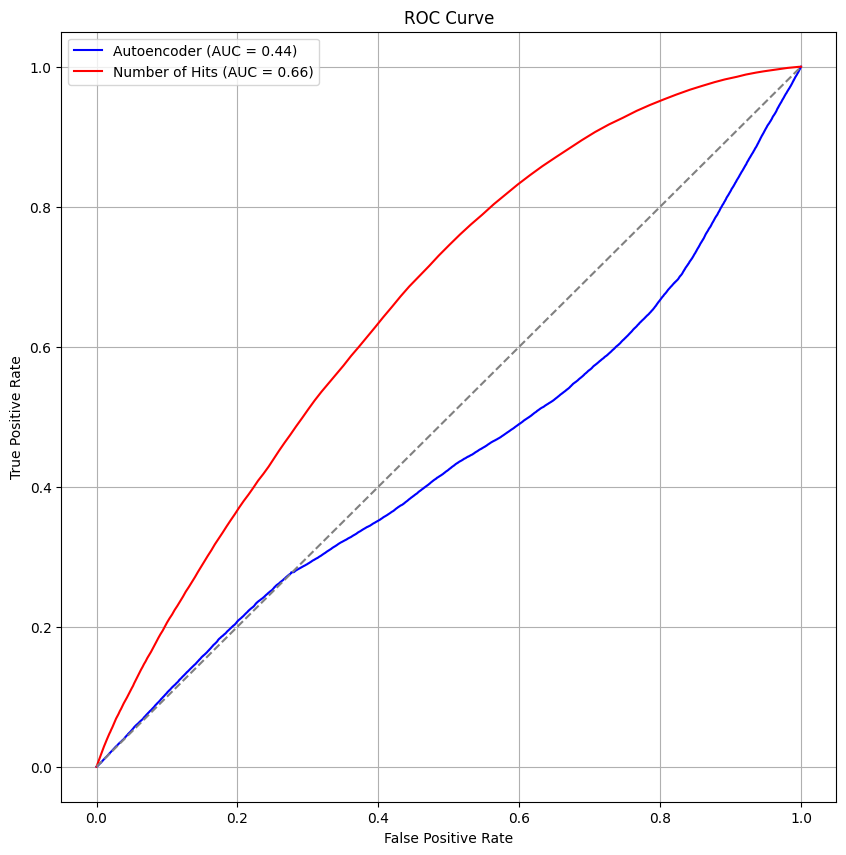

In [15]:
plt.figure(figsize=(10, 10))
plt.plot(fpr_autoencoder, tpr_autoencoder, label=f"Autoencoder (AUC = {roc_auc_autoencoder:.2f})", color="blue")
plt.plot(fpr_hits, tpr_hits, label=f"Number of Hits (AUC = {roc_auc_hits:.2f})", color="red")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

Text(0.5, 0, 'Difference')

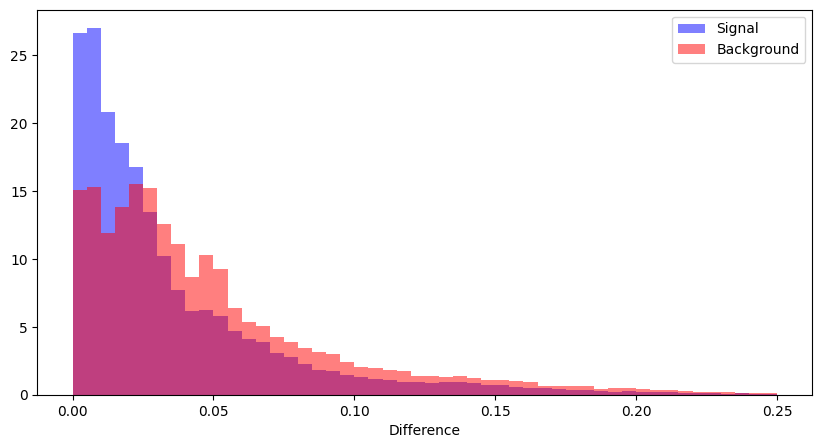

In [16]:
plt.figure(figsize=(10, 5))
plt.hist(signal_diff, bins=50, alpha=0.5, label="Signal", color="blue", density=True, range=(0,0.25))
plt.hist(background_diff, bins=50, alpha=0.5, label="Background", color="red", density=True, range=(0,0.25))
plt.legend()
plt.xlabel("Difference")